In [1]:
import os
import cv2
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set gaya visualisasi agar estetik dan profesional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

# Definisikan path absolut sesuai workspace kamu (Fokus ke data TRAIN)
IMAGE_DIR = "/content/drive/MyDrive/INA_AI_DATASET/train/images"
LABEL_DIR = "/content/drive/MyDrive/INA_AI_DATASET/train/labels"

print(f"Konfigurasi selesai. EDA akan mendeteksi data training di: {LABEL_DIR}")

Konfigurasi selesai. EDA akan mendeteksi data training di: /content/drive/MyDrive/INA_AI_DATASET/train/labels


In [2]:
# List untuk menampung data statistik
class_counts = []
box_data = []
objects_per_image = []

# Ambil semua file .txt di folder labels
label_files = glob.glob(os.path.join(LABEL_DIR, "*.txt"))

# Mapping nama kelas sesuai indeks YOLO dataset Ndomalau
class_mapping = {
    0: 'helmet',
    1: 'vest',
    2: 'no-helmet',
    3: 'person',
    4: 'no-vest'
}

for file_path in label_files:
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # Hitung kepadatan objek per gambar
    objects_per_image.append(len(lines))

    for line in lines:
        data = line.strip().split()
        if len(data) == 5:
            class_id = int(data[0])
            x_center = float(data[1])
            y_center = float(data[2])
            w_rel = float(data[3])
            h_rel = float(data[4])

            # Konversi rasio relatif ke ukuran piksel absolut (Basis gambar: 664x664)
            w_abs = w_rel * 664
            h_abs = h_rel * 664
            area = w_abs * h_abs

            class_counts.append(class_mapping.get(class_id, f'unknown_{class_id}'))
            box_data.append({
                'class_name': class_mapping.get(class_id, f'unknown_{class_id}'),
                'width_px': w_abs,
                'height_px': h_abs,
                'area_px': area,
                'x_center': x_center,
                'y_center': y_center
            })

df_boxes = pd.DataFrame(box_data)
print(f"Berhasil menganalisis {len(label_files)} file gambar/anotasi.")
print(f"Total objek (bounding boxes) yang ditemukan: {len(df_boxes)}")

Berhasil menganalisis 3248 file gambar/anotasi.
Total objek (bounding boxes) yang ditemukan: 24184


/tmp/ipykernel_4498/3545442908.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Total Objek', y='Kelas K3', data=df_counts, palette='viridis')


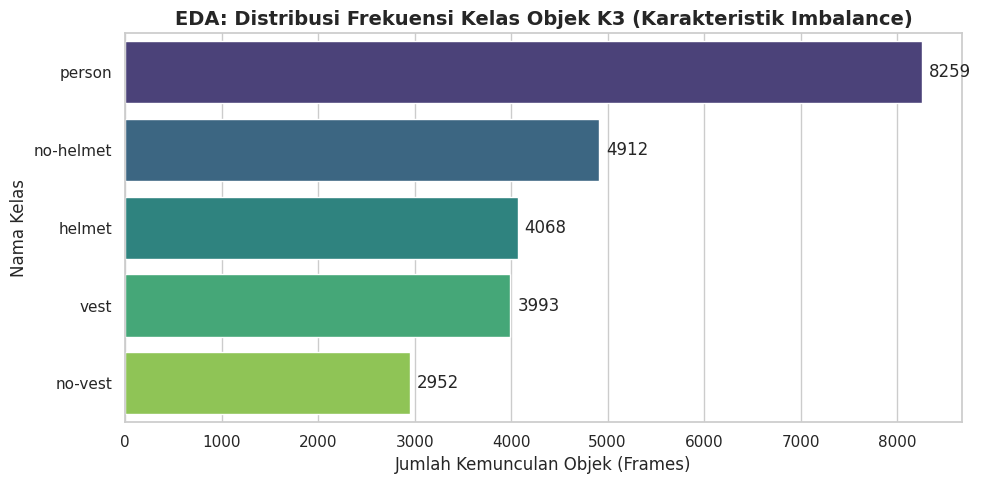

== ANALISIS WAKIL KELAS == 
Kelas [no-vest]: 2952 objek (12.21%)
Kelas [helmet]: 4068 objek (16.82%)
Kelas [person]: 8259 objek (34.15%)
Kelas [vest]: 3993 objek (16.51%)
Kelas [no-helmet]: 4912 objek (20.31%)


In [3]:
# 1. Hitung frekuensi tiap kelas
counts = Counter(class_counts)
df_counts = pd.DataFrame(counts.items(), columns=['Kelas K3', 'Total Objek']).sort_values(by='Total Objek', ascending=False)

# 2. Gambar Grafik Batang
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Total Objek', y='Kelas K3', data=df_counts, palette='viridis')

# Tambahkan label angka di ujung bar grafik
for i in ax.containers:
    ax.bar_label(i, padding=5)

plt.title('EDA: Distribusi Frekuensi Kelas Objek K3 (Karakteristik Imbalance)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Kemunculan Objek (Frames)', fontsize=12)
plt.ylabel('Nama Kelas', fontsize=12)
plt.tight_layout()
plt.show()

# Tampilkan insight teks untuk analisis laporan
print("== ANALISIS WAKIL KELAS == ")
for kelas, total in counts.items():
    persentase = (total / len(df_boxes)) * 100
    print(f"Kelas [{kelas}]: {total} objek ({persentase:.2f}%)")

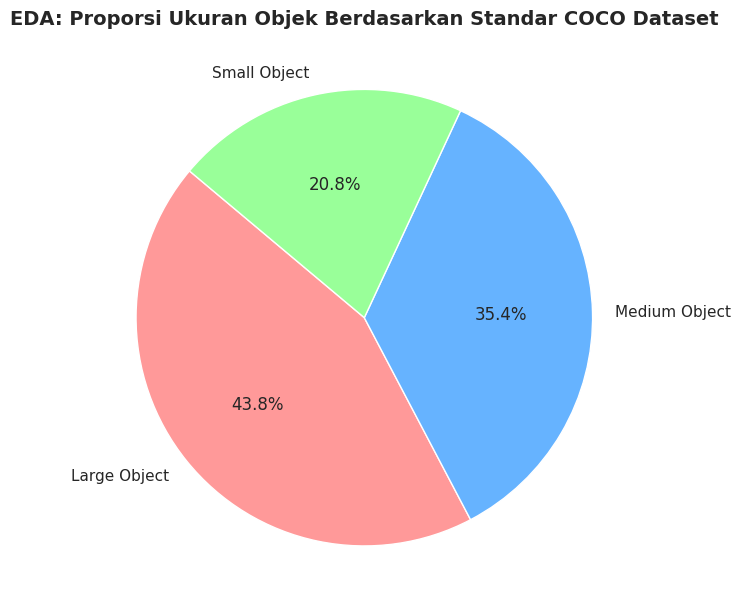

== ANALISIS SKALA OBJEK ==
coco_scale
Large Object     10597
Medium Object     8553
Small Object      5034
Name: count, dtype: int64


In [4]:
# Kategorisasi berdasarkan standar COCO
def categorize_coco(area):
    if area < 1024:  # 32^2 piksel
        return 'Small Object'
    elif area <= 9216:  # 96^2 piksel
        return 'Medium Object'
    else:
        return 'Large Object'

df_boxes['coco_scale'] = df_boxes['area_px'].apply(categorize_coco)
scale_counts = df_boxes['coco_scale'].value_counts()

# Gambar Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(scale_counts, labels=scale_counts.index, autopct='%1.1f%%', startangle=140,
        colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('EDA: Proporsi Ukuran Objek Berdasarkan Standar COCO Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("== ANALISIS SKALA OBJEK ==")
print(scale_counts)

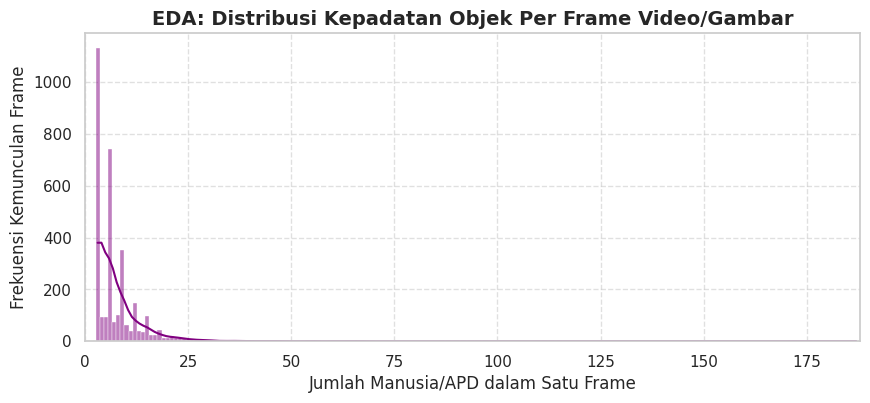

Rata-rata kepadatan objek per frame: 7.45 objek.
Kepadatan objek tertinggi dalam satu area: 187 objek.


In [5]:
plt.figure(figsize=(10, 4))
sns.histplot(objects_per_image, bins=range(1, max(objects_per_image)+2), kde=True, color='purple', discrete=True)
plt.title('EDA: Distribusi Kepadatan Objek Per Frame Video/Gambar', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Manusia/APD dalam Satu Frame', fontsize=12)
plt.ylabel('Frekuensi Kemunculan Frame', fontsize=12)
plt.xlim(0, max(objects_per_image)+1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Rata-rata kepadatan objek per frame: {np.mean(objects_per_image):.2f} objek.")
print(f"Kepadatan objek tertinggi dalam satu area: {max(objects_per_image)} objek.")

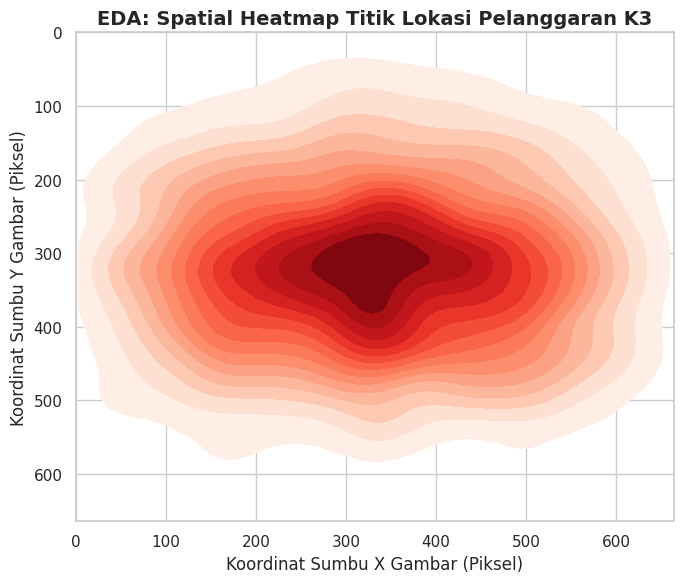

In [6]:
# Filter data khusus kelas pelanggaran
df_violations = df_boxes[df_boxes['class_name'].isin(['no-helmet', 'no-vest'])]

# Buat kanvas kosong 2D untuk density mapping
plt.figure(figsize=(7, 6))
sns.kdeplot(
    x=df_violations['x_center'] * 664,
    y=df_violations['y_center'] * 664,
    cmap="Reds",
    fill=True,
    thresh=0.05,
    levels=15
)

plt.title('EDA: Spatial Heatmap Titik Lokasi Pelanggaran K3', fontsize=14, fontweight='bold')
plt.xlabel('Koordinat Sumbu X Gambar (Piksel)', fontsize=12)
plt.ylabel('Koordinat Sumbu Y Gambar (Piksel)', fontsize=12)
plt.xlim(0, 664)
plt.ylim(664, 0) # Dibalik agar koordinat (0,0) di kiri atas sesuai format OpenCV
plt.tight_layout()
plt.show()